# Curvas de LTV | 2025 ate abril/2026

Este notebook busca dados reais no BigQuery, usando a tabela informada. Ele nao cria dados ficticios.

Objetivo:
- Fazer a curva de LTV por canal: DIGITAL, NAC e UNIDADES.
- Fazer a curva de LTV por subcanal: Paid Search, Paid Social, Sites Monomarcas, Search Organic e CRM.

Como ler a curva: o eixo X mostra quantos meses se passaram desde a aquisicao do paciente. O eixo Y mostra o LTV medio acumulado por paciente.

In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
from google.cloud import bigquery
from google.cloud import bigquery_storage

## 1. Configuracao

Aqui ficam os parametros principais. A data final e exclusiva: `2026-05-01` significa que vamos pegar dados ate abril/2026.

In [3]:
CANAIS_ANALISE = ["DIGITAL", "NAC", "UNIDADES"]
SUBCANAIS_ANALISE = [
    "Paid Search",
    "Paid Social",
    "Sites Monomarca",
    "Search Organic",
    "CRM",
    "Organic Social"
]

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

## 2. Query

A query faz quatro coisas:

1. Pega atendimentos de 2025 ate abril/2026.
2. Encontra a coorte de aquisicao, ou seja, o primeiro mes em que o paciente aparece como `novo`.
3. Soma a receita de cada paciente por mes depois da aquisicao.
4. Calcula o LTV acumulado por coorte.

In [4]:
query = (
"""
WITH base_eventos AS (
  SELECT
    nu_cpf_paciente AS paciente_id,
    DATE_TRUNC(mes_atendimento, MONTH) AS mes_atendimento,
    COALESCE(origem_agd, 'Nao Identificado') AS canal_aquisicao,
    COALESCE(channel_group, 'Nao Identificado') AS subcanal_aquisicao,
    classificacao_paciente_dasa,
    receita
  FROM prj-analytics-ga.testes.tb_temporal_class_pac_atd2
  WHERE mes_atendimento >= DATE "2023-01-01"
    AND mes_atendimento < DATE "2026-05-01"
    AND classificacao_paciente_dasa IN ('novo', 'recorrente', 'recuperado')
),

coorte_aquisicao AS (
  SELECT
    paciente_id,
    mes_atendimento AS mes_coorte,
    canal_aquisicao,
    subcanal_aquisicao
  FROM base_eventos
  WHERE classificacao_paciente_dasa = 'novo'
  QUALIFY ROW_NUMBER() OVER (
    PARTITION BY paciente_id
    ORDER BY mes_atendimento ASC
  ) = 1
),

tamanho_coorte AS (
  SELECT
    canal_aquisicao,
    subcanal_aquisicao,
    mes_coorte,
    COUNT(DISTINCT paciente_id) AS tamanho_coorte
  FROM coorte_aquisicao
  GROUP BY 1, 2, 3
),

receita_por_mes AS (
  SELECT
    paciente_id,
    mes_atendimento,
    SUM(receita) AS receita_mes
  FROM base_eventos
  GROUP BY 1, 2
),

coorte_receita AS (
  SELECT
    c.paciente_id,
    c.mes_coorte,
    c.canal_aquisicao,
    c.subcanal_aquisicao,
    r.mes_atendimento,
    DATE_DIFF(r.mes_atendimento, c.mes_coorte, MONTH) AS mes_desde_aquisicao,
    r.receita_mes
  FROM coorte_aquisicao c
  INNER JOIN receita_por_mes r
    ON r.paciente_id = c.paciente_id
   AND r.mes_atendimento >= c.mes_coorte
),

receita_mensal AS (
  SELECT
    canal_aquisicao,
    subcanal_aquisicao,
    mes_coorte,
    mes_atendimento,
    mes_desde_aquisicao,
    COUNT(DISTINCT paciente_id) AS pacientes_ativos,
    SUM(receita_mes) AS receita_mes
  FROM coorte_receita
  GROUP BY 1, 2, 3, 4, 5
),

base_final AS (
  SELECT
    r.canal_aquisicao,
    r.subcanal_aquisicao,
    r.mes_coorte,
    r.mes_atendimento,
    r.mes_desde_aquisicao,
    r.pacientes_ativos,
    c.tamanho_coorte,
    r.receita_mes,
    SUM(r.receita_mes) OVER (
      PARTITION BY r.canal_aquisicao, r.subcanal_aquisicao, r.mes_coorte
      ORDER BY r.mes_desde_aquisicao
      ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
    ) AS receita_acumulada
  FROM receita_mensal r
  LEFT JOIN tamanho_coorte c
    ON r.canal_aquisicao = c.canal_aquisicao
   AND r.subcanal_aquisicao = c.subcanal_aquisicao
   AND r.mes_coorte = c.mes_coorte
)

SELECT
  canal_aquisicao,
  subcanal_aquisicao,
  mes_coorte,
  mes_atendimento,
  mes_desde_aquisicao,
  pacientes_ativos,
  tamanho_coorte,
  ROUND(receita_mes, 2) AS receita_mes,
  ROUND(receita_acumulada, 2) AS receita_acumulada,
  ROUND(receita_acumulada / NULLIF(tamanho_coorte, 0), 2) AS ltv_medio_por_paciente
FROM base_final
ORDER BY canal_aquisicao, subcanal_aquisicao, mes_coorte, mes_desde_aquisicao
"""
)

## 3. Carregar dados

Esta celula executa a query no BigQuery. Se der erro aqui, o problema esta na permissao, autenticacao, nome da tabela ou nome de alguma coluna.

In [5]:
client = bigquery.Client()
bqstorage_client = bigquery_storage.BigQueryReadClient()

df = client.query(query).result().to_dataframe(bqstorage_client=bqstorage_client)

df["mes_coorte"] = pd.to_datetime(df["mes_coorte"])
df["mes_atendimento"] = pd.to_datetime(df["mes_atendimento"])
df["mes_desde_aquisicao"] = df["mes_desde_aquisicao"].astype(int)

print(f"Linhas carregadas: {len(df):,}")
print(f"Coortes: {df['mes_coorte'].min()} -> {df['mes_coorte'].max()}")
print(f"Atendimentos: {df['mes_atendimento'].min()} -> {df['mes_atendimento'].max()}")
df.head()

Linhas carregadas: 9,148
Coortes: 2023-01-01 00:00:00 -> 2026-04-01 00:00:00
Atendimentos: 2023-01-01 00:00:00 -> 2026-04-01 00:00:00


,canal_aquisicao,subcanal_aquisicao,mes_coorte,mes_atendimento,mes_desde_aquisicao,pacientes_ativos,tamanho_coorte,receita_mes,receita_acumulada,ltv_medio_por_paciente
0,DIGITAL,Blog,2025-07-01,2025-07-01,0,3,3,305.10,305.10,101.70
1,DIGITAL,Blog,2025-08-01,2025-08-01,0,19,18,30456.53,30456.53,1692.03
2,DIGITAL,Blog,2025-08-01,2025-09-01,1,2,18,17247.60,47704.13,2650.23
3,DIGITAL,Blog,2025-08-01,2025-11-01,3,1,18,7832.00,55536.13,3085.34
4,DIGITAL,Blog,2025-08-01,2025-12-01,4,1,18,273.00,55809.13,3100.51


In [6]:
## 7. Tabela Resumo por Canal: Ticket Médio, Frequência Anual e Retenção (anos)
#
# Fórmula: LTV = Ticket Médio × Frequência Anual × Tempo de Retenção (anos)
#
# Ticket Médio    = receita total / total de atendimentos (pacientes-mês com receita > 0)
# Frequência Anual = atendimentos por paciente por ano
#                  = (total de meses com atendimento / pacientes únicos da coorte) * (12 / janela_meses)
# Retenção (anos) = tempo médio que um paciente permanece ativo
#                  = média ponderada dos meses desde aquisição dos últimos atendimentos / 12

import numpy as np

resultados = []

for canal in CANAIS_ANALISE:
    g = df[df["canal_aquisicao"] == canal].copy()

    if g.empty:
        continue

    # ── Tamanho total de coorte (pacientes únicos adquiridos) ──────────────────
    tamanho_total = g.drop_duplicates(subset=["mes_coorte"]).groupby("mes_coorte")["tamanho_coorte"].first().sum()

    # ── Janela de observação em meses ─────────────────────────────────────────
    janela_meses = g["mes_desde_aquisicao"].max()  # meses máximos observados

    # ── TICKET MÉDIO ──────────────────────────────────────────────────────────
    # Receita total dividida pelo total de atendimentos (meses-paciente com presença)
    receita_total = g["receita_mes"].sum()
    total_atendimentos = g["pacientes_ativos"].sum()  # soma de presença mensal = total de atendimentos
    ticket_medio = receita_total / total_atendimentos if total_atendimentos > 0 else 0

    # / janela_anos

    # ── FREQUÊNCIA ANUAL ──────────────────────────────────────────────────────
    # Quantas vezes por ano um paciente vai, em média
    # = (total de atendimentos / pacientes únicos) / (janela em anos)
    janela_anos = janela_meses / 12
    frequencia_anual = (total_atendimentos / tamanho_total)  if (tamanho_total > 0 and janela_anos > 0) else 0

    # ── RETENÇÃO (anos) ───────────────────────────────────────────────────────
    # Para cada coorte: último mês com atendimento = quanto tempo o paciente ficou ativo
    # Retenção média = média ponderada pelo tamanho de cada coorte
    ultimo_mes_por_coorte = (
        g.groupby("mes_coorte")
         .agg(
             ultimo_mes=("mes_desde_aquisicao", "max"),
             tamanho_coorte=("tamanho_coorte", "first")
         )
         .reset_index()
    )
    retencao_anos = (
        np.average(ultimo_mes_por_coorte["ultimo_mes"], weights=ultimo_mes_por_coorte["tamanho_coorte"]) / 12
    )

    # ── LTV calculado (validação) ──────────────────────────────────────────────
    ltv_calculado = ticket_medio * frequencia_anual * retencao_anos

    resultados.append({
        "CANAIS": canal,
        "TICKET MÉDIO": ticket_medio,
        "FREQUÊNCIA ANUAL": frequencia_anual,
        "RETENÇÃO (anos)": retencao_anos,
        "LTV (validação)": ltv_calculado,
    })

tabela_resumo = pd.DataFrame(resultados).set_index("CANAIS")

# ── Exibir formatado ──────────────────────────────────────────────────────────
tabela_formatada = tabela_resumo.copy()
tabela_formatada["TICKET MÉDIO"]      = tabela_resumo["TICKET MÉDIO"].apply(lambda v: f"R$ {v:,.2f}".replace(",","X").replace(".",",").replace("X","."))
tabela_formatada["FREQUÊNCIA ANUAL"]  = tabela_resumo["FREQUÊNCIA ANUAL"].apply(lambda v: f"{v:.1f}x/ano")
tabela_formatada["RETENÇÃO (anos)"]   = tabela_resumo["RETENÇÃO (anos)"].apply(lambda v: f"{v:.1f} anos")
tabela_formatada["LTV (validação)"]   = tabela_resumo["LTV (validação)"].apply(lambda v: f"R$ {v:,.2f}".replace(",","X").replace(".",",").replace("X","."))

print("=" * 70)
print("   RESUMO LTV POR CANAL")
print("=" * 70)
print(tabela_formatada.to_string())
print("=" * 70)

tabela_formatada

   RESUMO LTV POR CANAL
         TICKET MÉDIO FREQUÊNCIA ANUAL RETENÇÃO (anos)  LTV (validação)
CANAIS                                                                 
DIGITAL   R$ 6.701,54       191.0x/ano        1.5 anos  R$ 1.936.002,12
NAC       R$ 6.447,46         2.0x/ano        1.5 anos     R$ 18.939,59
UNIDADES  R$ 3.689,64         2.0x/ano        1.6 anos     R$ 11.509,31


,TICKET MÉDIO,FREQUÊNCIA ANUAL,RETENÇÃO (anos),LTV (validação)
CANAIS,,,,
DIGITAL,"R$ 6.701,54",191.0x/ano,1.5 anos,"R$ 1.936.002,12"
NAC,"R$ 6.447,46",2.0x/ano,1.5 anos,"R$ 18.939,59"
UNIDADES,"R$ 3.689,64",2.0x/ano,1.6 anos,"R$ 11.509,31"


In [7]:
df_canais = df.groupby("canal_aquisicao").agg(
    pacientes_ativos=("pacientes_ativos", "sum")
)

df_canais["percentual"] = (
    df_canais["pacientes_ativos"] / df_canais["pacientes_ativos"].sum()
)

df_canais

,pacientes_ativos,percentual
canal_aquisicao,,
DIGITAL,1075170,0.082275
NAC,2251135,0.172263
UNIDADES,9741740,0.745463


## 4. Funcoes de agregacao e grafico

Aqui nao buscamos dados novos. So transformamos o dataframe carregado na celula anterior.

O ponto da curva e calculado assim: soma da receita acumulada das coortes dividida pela soma do tamanho das coortes.

In [8]:
def formatar_reais(valor: float) -> str:
    return f"R$ {valor:,.0f}".replace(",", ".")


def agregar_curva_ltv(df_base: pd.DataFrame, coluna_grupo: str, grupos: list[str]) -> pd.DataFrame:
    df_plot = df_base[df_base[coluna_grupo].isin(grupos)].copy()

    if df_plot.empty:
        print(f"Nenhum dado encontrado para {coluna_grupo}: {grupos}")
        return df_plot

    # Usa receita_acumulada do SQL diretamente (já é cumulativa por coorte)
    # Média ponderada pelo tamanho de cada coorte
    mensal = (
        df_plot
        .groupby([coluna_grupo, "mes_desde_aquisicao"], as_index=False)
        .agg(
            receita_acumulada_total=("receita_acumulada", "sum"),
            pacientes=("tamanho_coorte", "sum"),
        )
    )

    mensal["ltv_acumulado"] = mensal["receita_acumulada_total"] / mensal["pacientes"]

    return mensal


def plotar_curva(df_curva: pd.DataFrame, coluna_grupo: str, grupos: list[str], titulo: str, caminho_saida: Path) -> None:
    if df_curva.empty:
        return

    fig, ax = plt.subplots(figsize=(17, 7))
    max_mes = df_curva["mes_desde_aquisicao"].max()

    for grupo in grupos:
        dados = df_curva[df_curva[coluna_grupo] == grupo].sort_values("mes_desde_aquisicao")
        if dados.empty:
            print(f"Sem dados para: {grupo}")
            continue

        
        ax.plot(
            dados["mes_desde_aquisicao"],
            dados["ltv_acumulado"],
            marker="o",
            linewidth=2.5,
            label=grupo,

        )

        ultimo = dados.iloc[-1]
        ax.annotate(           
            f"{grupo}\n{formatar_reais(ultimo['ltv_acumulado'])}",
            xy=(ultimo["mes_desde_aquisicao"], ultimo["ltv_acumulado"]),
            xytext=(8, 0),
            textcoords="offset points",
            fontsize=8,
            fontweight="bold"

        )

    ax.set_title(titulo, fontsize=14, fontweight="bold", pad=15)
    ax.set_xlabel("Meses desde a aquisicao")
    ax.set_ylabel("LTV medio por paciente")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: formatar_reais(x)))
    ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
    ax.set_xlim(left=0, right=max_mes + 2.5)
    ax.grid(axis="y", alpha=0.3)
    ax.grid(axis="x", alpha=0.15)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout(rect=[0, 0, 0.84, 1])
    plt.savefig(caminho_saida, dpi=150, bbox_inches="tight")
    plt.show()

## 5. Curva por canal

Aqui filtramos apenas os canais pedidos: DIGITAL, NAC e UNIDADES.

In [9]:
# Análise de subcanais do DIGITAL por mês
df[df["canal_aquisicao"] == "DIGITAL"].groupby(
    ["subcanal_aquisicao", "mes_desde_aquisicao"]
).agg(
    tamanho_coorte=("tamanho_coorte", "first"),
    ltv=("ltv_medio_por_paciente", "mean")
).reset_index().pivot(
    index="mes_desde_aquisicao", 
    columns="subcanal_aquisicao", 
    values="ltv"
)

subcanal_aquisicao,Blog,CRM,Dial My App,Direto,Fluxos NAC,IAs,Nao Identificado,Organic Social,Outros,Paid Search,Paid Social,QR Code,Referral,Search Organic,Sites Monomarca
mes_desde_aquisicao,,,,,,,,,,,,,,,
0,2344.975000,7585.756000,4771.997222,6434.540500,2962.256842,4718.763333,5931.538250,1298.172778,5694.181750,5133.337750,2361.564194,6475.474615,5419.705000,7195.040500,4475.186250
1,3214.077143,9040.194103,10729.355000,8002.725897,3810.565556,4960.280000,7310.984103,2770.483333,7021.175128,6300.274872,4154.038235,10809.144762,6726.393947,8734.082821,5511.890769
2,4170.426000,10023.850000,20503.300000,9109.328947,4400.942941,NaN,8395.985263,1335.405000,7899.435789,7134.680000,5083.791765,10071.701667,7283.097568,9882.402368,6252.335526
3,3975.353333,10897.969189,5313.817500,10077.447027,4944.465625,20503.350000,9311.436486,1070.860000,8665.796486,7863.715135,4707.928750,11194.441176,8087.663714,10885.759189,6903.538649
4,4947.667500,11852.538056,10327.930000,11009.932222,5481.880000,NaN,10201.008889,15510.000000,9455.322222,8549.971944,6337.310714,15161.712222,8829.987812,11769.852222,7545.931667
5,2902.390000,12699.080000,11592.900000,11920.608857,6049.507143,NaN,11033.128571,NaN,10220.088571,9192.428000,7449.098462,15221.102778,9282.551765,12643.717429,8177.722857
6,5825.600000,13625.775588,16473.175000,12785.600000,6577.464615,NaN,11859.525000,NaN,10936.934412,9855.745000,7250.532143,16786.260667,10170.022353,13541.465000,8790.441765
7,8610.260000,14558.344848,22134.326667,13626.608788,7121.594167,5926.520000,12683.146061,NaN,11643.143030,10453.720000,5919.644286,17930.068824,10963.530000,14336.899697,9373.899091
8,3268.140000,15338.605000,9637.540000,14422.898125,7672.111818,NaN,13476.796875,NaN,12357.567812,11060.660313,6202.202000,18333.205000,11643.487667,15195.616875,9943.197187


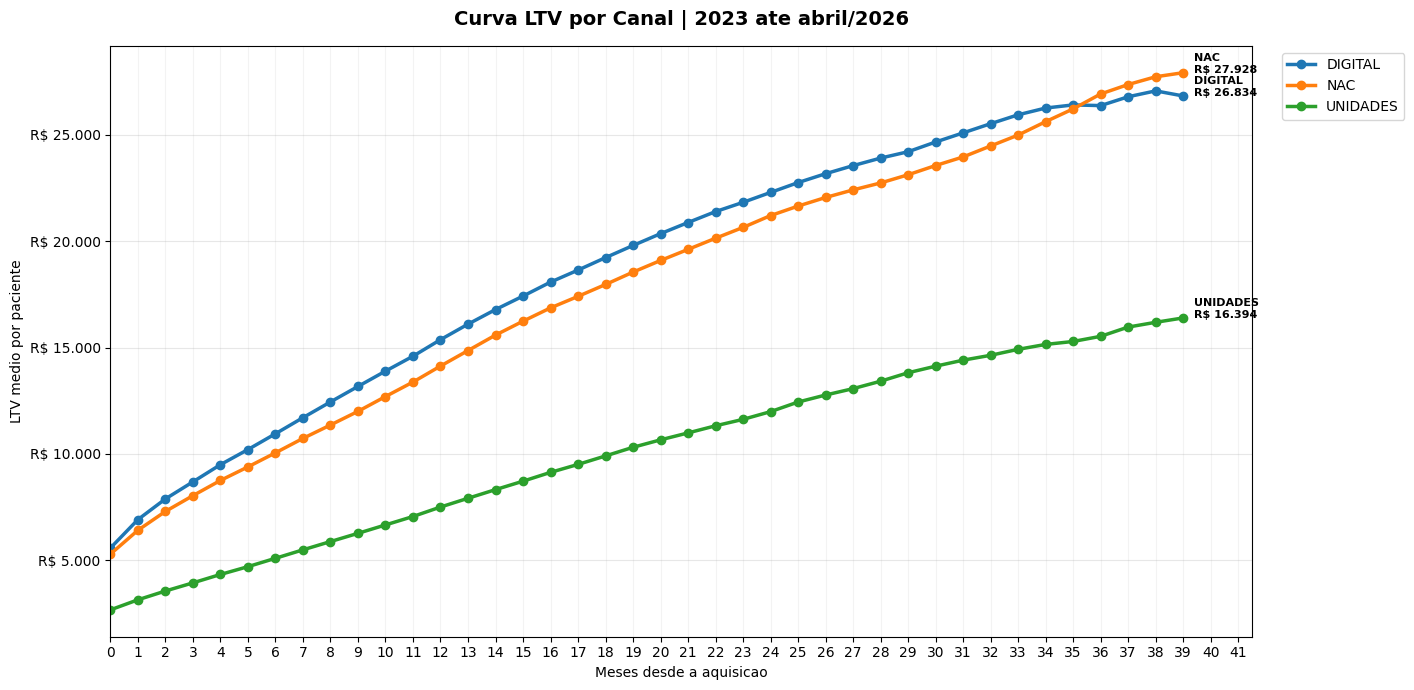

In [10]:
curva_canais = agregar_curva_ltv(df, "canal_aquisicao", CANAIS_ANALISE)


plotar_curva(
    curva_canais,
    "canal_aquisicao",
    CANAIS_ANALISE,
    "Curva LTV por Canal | 2023 ate abril/2026",
    caminho_saida= OUTPUT_DIR / "curva_ltv_canal.png"
)

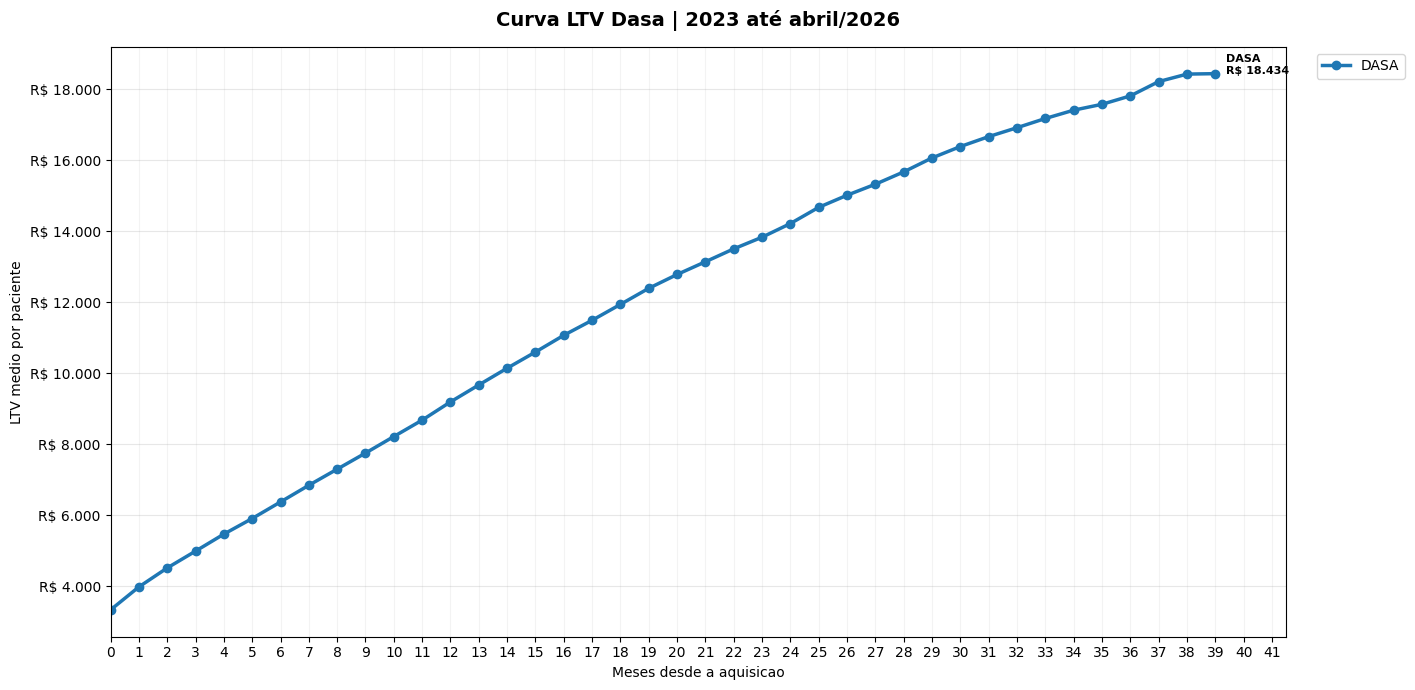

In [11]:
df["canais_analise"] = np.where(
    df["canal_aquisicao"].isin(CANAIS_ANALISE),
    "DASA",
    df["canal_aquisicao"]
)

curva_dasa = agregar_curva_ltv(
    df,
    "canais_analise",
    ["DASA"]
)

plotar_curva(
    curva_dasa,
    "canais_analise",
    ["DASA"],
    "Curva LTV Dasa | 2023 até abril/2026",
    caminho_saida=OUTPUT_DIR / "curva_ltv_dasa.png"
)


## 6. Curva por subcanal

Aqui filtramos apenas os subcanais pedidos. Se algum nome estiver diferente na tabela, a celula vai imprimir os valores disponiveis para voce conferir.

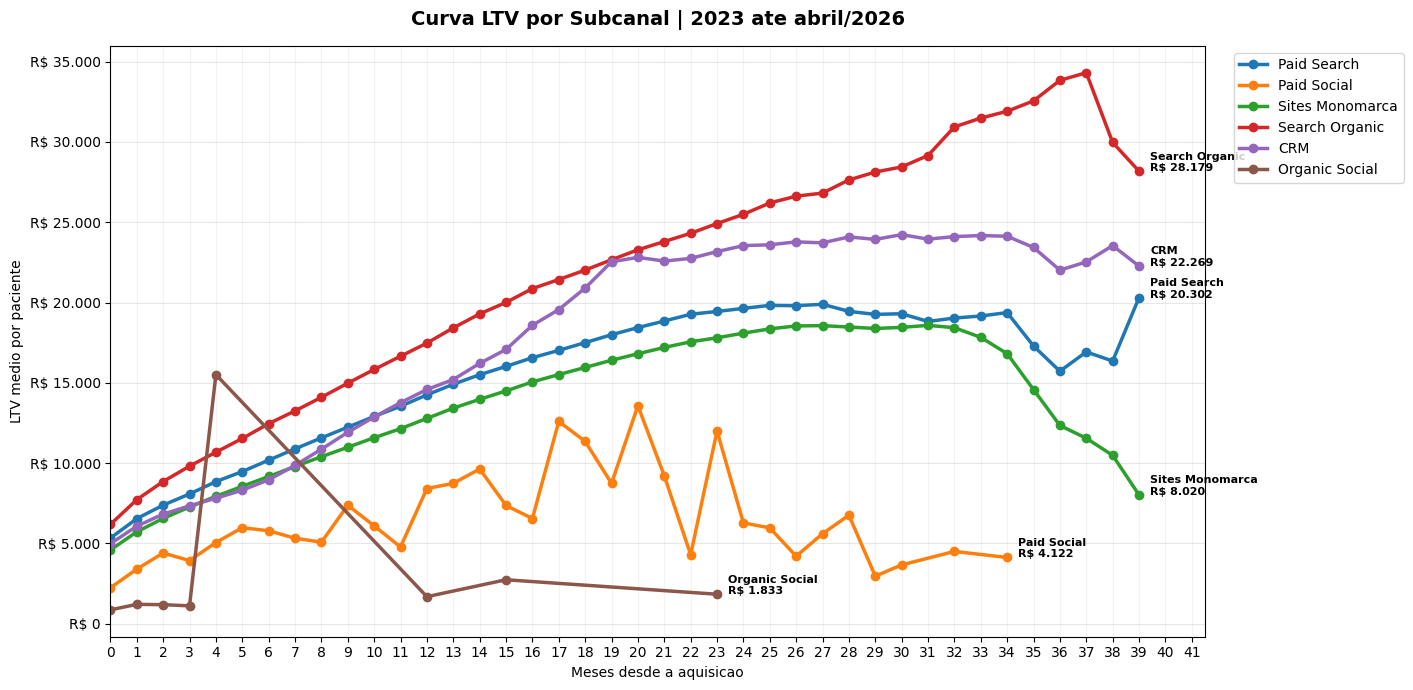

In [12]:
curva_subcanais = agregar_curva_ltv(df, "subcanal_aquisicao", SUBCANAIS_ANALISE)

plotar_curva(
    curva_subcanais,
    "subcanal_aquisicao",
    SUBCANAIS_ANALISE,
    "Curva LTV por Subcanal | 2023 ate abril/2026",
    caminho_saida= OUTPUT_DIR / "curva_ltv_subcanal.png"
)

In [13]:
def formatar_reais(valor):
    return f"R$ {valor:,.0f}".replace(",", "X").replace(".", ",").replace("X", ".")


def criar_base_matriz_retencao_ltv(
    df_base,
    coluna_grupo="canal_aquisicao",
    grupos=None,
    mes_retencao=12
):
    df_matriz = df_base.copy()

    if grupos is not None:
        df_matriz = df_matriz[df_matriz[coluna_grupo].isin(grupos)].copy()

    if df_matriz.empty:
        print("Nenhum dado encontrado.")
        return pd.DataFrame()

    resultados = []

    for grupo, g in df_matriz.groupby(coluna_grupo):

        # -----------------------------
        # 1. LTV acumulado final
        # -----------------------------
        # Para cada coorte, pega o último mês observado daquela coorte
        ultimos_pontos = (
            g.sort_values("mes_desde_aquisicao")
             .groupby(["mes_coorte"], as_index=False)
             .tail(1)
        )

        receita_acumulada_total = ultimos_pontos["receita_acumulada"].sum()
        tamanho_total_coortes = ultimos_pontos["tamanho_coorte"].sum()

        ltv_final = (
            receita_acumulada_total / tamanho_total_coortes
            if tamanho_total_coortes > 0
            else np.nan
        )

        # -----------------------------
        # 2. Retenção no mês escolhido
        # -----------------------------
        g_mes_retencao = g[g["mes_desde_aquisicao"] == mes_retencao].copy()

        if g_mes_retencao.empty:
            retencao = np.nan
        else:
            pacientes_ativos = g_mes_retencao["pacientes_ativos"].sum()
            tamanho_coortes_retencao = g_mes_retencao["tamanho_coorte"].sum()

            retencao = (
                pacientes_ativos / tamanho_coortes_retencao
                if tamanho_coortes_retencao > 0
                else np.nan
            )

        # -----------------------------
        # 3. Volume da coorte
        # -----------------------------
        volume_pacientes = (
            g.drop_duplicates(["mes_coorte"])["tamanho_coorte"].sum()
        )

        resultados.append({
            coluna_grupo: grupo,
            "ltv_final": ltv_final,
            "retencao": retencao,
            "volume_pacientes": volume_pacientes,
            "mes_retencao": mes_retencao
        })

    return pd.DataFrame(resultados)

In [14]:
matriz_canais = criar_base_matriz_retencao_ltv(
    df_base=df,
    coluna_grupo="canal_aquisicao",
    grupos=CANAIS_ANALISE,
    mes_retencao=12
)

matriz_canais

,canal_aquisicao,ltv_final,retencao,volume_pacientes,mes_retencao
0,DIGITAL,13097.846851,0.061416,5629,12
1,NAC,12701.775357,0.053655,1142683,12
2,UNIDADES,7269.208495,0.059474,4944620,12


In [15]:
def plotar_matriz_retencao_ltv(
    df_matriz,
    coluna_grupo="canal_aquisicao",
    titulo="Matriz Retenção x LTV",
    caminho_saida=None
):
    dados = df_matriz.dropna(subset=["ltv_final", "retencao"]).copy()

    if dados.empty:
        print("Sem dados suficientes para plotar a matriz.")
        return

    corte_ltv = dados["ltv_final"].median()
    corte_retencao = dados["retencao"].median()

    fig, ax = plt.subplots(figsize=(13, 7))

    tamanhos = dados["volume_pacientes"] / dados["volume_pacientes"].max() * 1200

    ax.scatter(
        dados["retencao"],
        dados["ltv_final"],
        s=tamanhos,
        alpha=0.65
    )

    for _, linha in dados.iterrows():
        ax.annotate(
            linha[coluna_grupo],
            xy=(linha["retencao"], linha["ltv_final"]),
            xytext=(8, 5),
            textcoords="offset points",
            fontsize=9,
            fontweight="bold"
        )

    # Linhas dos quadrantes
    ax.axvline(corte_retencao, linestyle="--", linewidth=1.5)
    ax.axhline(corte_ltv, linestyle="--", linewidth=1.5)

    # Textos dos quadrantes
    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()

    ax.text(
        x_min + (x_max - x_min) * 0.05,
        y_min + (y_max - y_min) * 0.08,
        "Rever aquisição\nRetenção baixa + LTV baixo",
        fontsize=10,
        fontweight="bold"
    )

    ax.text(
        x_min + (x_max - x_min) * 0.80,
        y_min + (y_max - y_min) * 0.08,
        "Nicho premium\nRetenção alta + LTV baixo",
        fontsize=10,
        fontweight="bold"
    )

    ax.text(
        x_min + (x_max - x_min) * 0.05,
        y_min + (y_max - y_min) * 0.82,
        "Fidelizados pouco rentáveis\nRetenção baixa + LTV alto",
        fontsize=10,
        fontweight="bold"
    )

    ax.text(
        x_min + (x_max - x_min) * 0.80,
        y_min + (y_max - y_min) * 0.82,
        "Clientes ideais\nRetenção alta + LTV alto",
        fontsize=10,
        fontweight="bold"
    )

    ax.set_title(titulo, fontsize=15, fontweight="bold", pad=15)
    ax.set_xlabel("Retenção")
    ax.set_ylabel("LTV acumulado médio por paciente")

    ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: formatar_reais(x))
    )

    ax.grid(alpha=0.25)

    plt.tight_layout()

    # if caminho_saida:
    #     plt.savefig(caminho_saida, dpi=150, bbox_inches="tight")

    # plt.show()

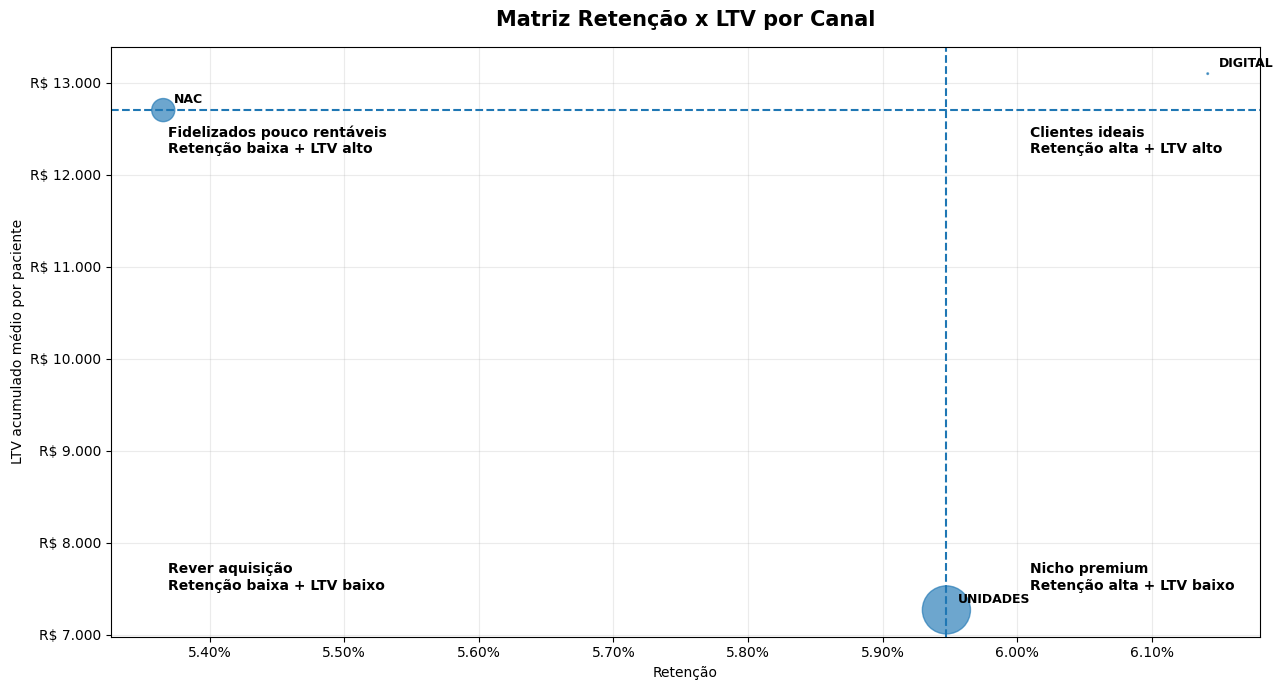

In [16]:
plotar_matriz_retencao_ltv(
    matriz_canais,
    coluna_grupo="canal_aquisicao",
    titulo="Matriz Retenção x LTV por Canal",
    caminho_saida=OUTPUT_DIR / "matriz_retencao_ltv_canal.png"
)

In [17]:
df_digital = df[df["subcanal_aquisicao"].isin(["CRM", "Direto", "Paid Search", "Paid Social", "Search Organic", "Sites Monomarca"])].copy()



matriz_subcanais_digital = criar_base_matriz_retencao_ltv(
    df_base=df_digital,
    coluna_grupo="subcanal_aquisicao",
    grupos=None,
    mes_retencao=12
)

matriz_subcanais_digital

,subcanal_aquisicao,ltv_final,retencao,volume_pacientes,mes_retencao
0,CRM,9944.152144,0.064501,12102,12
1,Direto,15407.171555,0.069966,81793,12
2,Paid Search,12564.223452,0.058401,112286,12
3,Paid Social,6011.698448,0.078740,522,12
4,Search Organic,13740.012881,0.069386,30472,12
5,Sites Monomarca,11841.220588,0.055551,116597,12


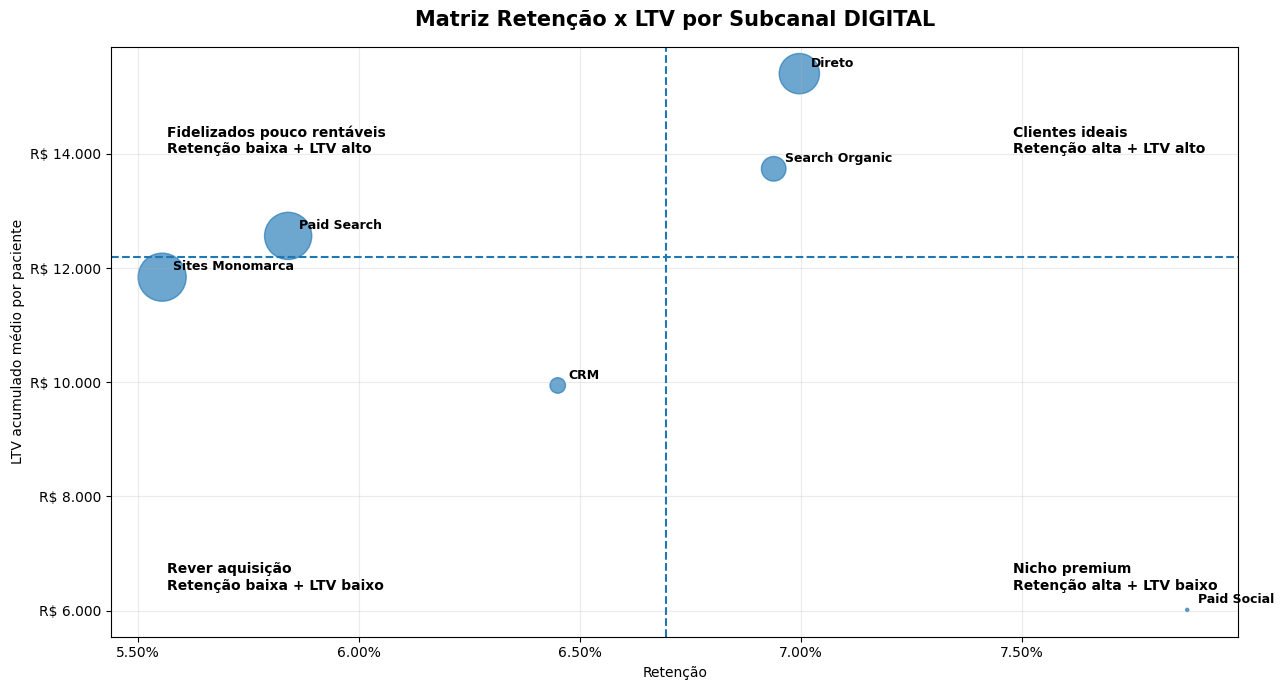

In [18]:
plotar_matriz_retencao_ltv(
    matriz_subcanais_digital,
    coluna_grupo="subcanal_aquisicao",
    titulo="Matriz Retenção x LTV por Subcanal DIGITAL",
    caminho_saida=OUTPUT_DIR / "matriz_retencao_ltv_subcanais_digital.png"
)

In [19]:
for mes in [3, 6, 12]:
    print(f"\n===== Retenção no mês {mes} =====")
    
    matriz_temp = criar_base_matriz_retencao_ltv(
        df_base=df,
        coluna_grupo="canal_aquisicao",
        grupos=CANAIS_ANALISE,
        mes_retencao=mes
    )
    
    display(
        matriz_temp[[
            "canal_aquisicao",
            "ltv_final",
            "retencao",
            "volume_pacientes",
        ]]
    )


===== Retenção no mês 3 =====


,canal_aquisicao,ltv_final,retencao,volume_pacientes
0,DIGITAL,13097.846851,0.080362,5629
1,NAC,12701.775357,0.067271,1142683
2,UNIDADES,7269.208495,0.059649,4944620



===== Retenção no mês 6 =====


,canal_aquisicao,ltv_final,retencao,volume_pacientes
0,DIGITAL,13097.846851,0.069307,5629
1,NAC,12701.775357,0.054964,1142683
2,UNIDADES,7269.208495,0.058223,4944620



===== Retenção no mês 12 =====


,canal_aquisicao,ltv_final,retencao,volume_pacientes
0,DIGITAL,13097.846851,0.061416,5629
1,NAC,12701.775357,0.053655,1142683
2,UNIDADES,7269.208495,0.059474,4944620


In [20]:
def criar_base_matriz_retencao_ltv_mes(
    df_base,
    coluna_grupo="canal_aquisicao",
    grupos=None,
    mes_referencia=6
):
    df_matriz = df_base.copy()

    if grupos is not None:
        df_matriz = df_matriz[df_matriz[coluna_grupo].isin(grupos)].copy()

    if df_matriz.empty:
        print("Base vazia após filtro.")
        return pd.DataFrame()

    data_fim_observacao = df_matriz["mes_atendimento"].max()

    resultados = []

    for grupo, g in df_matriz.groupby(coluna_grupo):

        chaves_coorte = ["canal_aquisicao", "subcanal_aquisicao", "mes_coorte"]

        coortes = (
            g[chaves_coorte + ["tamanho_coorte"]]
            .drop_duplicates()
            .copy()
        )

        coortes["idade_maxima_meses"] = (
            (data_fim_observacao.year - coortes["mes_coorte"].dt.year) * 12
            + (data_fim_observacao.month - coortes["mes_coorte"].dt.month)
        )

        coortes_elegiveis = coortes[
            coortes["idade_maxima_meses"] >= mes_referencia
        ].copy()

        if coortes_elegiveis.empty:
            resultados.append({
                coluna_grupo: grupo,
                "ltv": np.nan,
                "retencao": np.nan,
                "volume_pacientes": coortes["tamanho_coorte"].sum(),
                "coortes_elegiveis": 0,
                "mes_referencia": mes_referencia
            })
            continue

        # Filtra apenas as coortes elegíveis
        g_elegivel = g.merge(
            coortes_elegiveis[chaves_coorte],
            on=chaves_coorte,
            how="inner"
        )

        # -----------------------------
        # LTV acumulado até o mês escolhido
        # -----------------------------
        g_ltv_mes = g_elegivel[
            g_elegivel["mes_desde_aquisicao"] == mes_referencia
        ].copy()

        receita_acumulada_total = g_ltv_mes["receita_acumulada"].sum()

        tamanho_total = coortes_elegiveis["tamanho_coorte"].sum()

        ltv = (
            receita_acumulada_total / tamanho_total
            if tamanho_total > 0
            else np.nan
        )

        # -----------------------------
        # Retenção no mês escolhido
        # -----------------------------
        pacientes_ativos_mes = g_ltv_mes["pacientes_ativos"].sum()

        retencao = (
            pacientes_ativos_mes / tamanho_total
            if tamanho_total > 0
            else np.nan
        )

        volume_pacientes = coortes["tamanho_coorte"].sum()

        resultados.append({
            coluna_grupo: grupo,
            "ltv_final": ltv,
            "retencao": retencao,
            "volume_pacientes": volume_pacientes,
            "coortes_elegiveis": len(coortes_elegiveis),
            "mes_referencia": mes_referencia
        })

    return pd.DataFrame(resultados)

In [21]:
for mes in [3, 6, 12]:
    print(f"\n===== Mês referência {mes} =====")
    
    matriz_temp = criar_base_matriz_retencao_ltv_mes(
        df_base=df,
        coluna_grupo="canal_aquisicao",
        grupos=CANAIS_ANALISE,
        mes_referencia=mes
    )
    
    display(
        matriz_temp[[
            "canal_aquisicao",
            "ltv_final",
            "retencao",
            "volume_pacientes",
            "coortes_elegiveis"
        ]]
    )


===== Mês referência 3 =====


,canal_aquisicao,ltv_final,retencao,volume_pacientes,coortes_elegiveis
0,DIGITAL,8678.247351,0.080303,485879,420
1,NAC,8035.881076,0.067271,1142683,37
2,UNIDADES,3933.688534,0.059649,4944620,37



===== Mês referência 6 =====


,canal_aquisicao,ltv_final,retencao,volume_pacientes,coortes_elegiveis
0,DIGITAL,10938.771558,0.069257,485879,382
1,NAC,10049.815541,0.054964,1142683,34
2,UNIDADES,5089.746027,0.058223,4944620,34



===== Mês referência 12 =====


,canal_aquisicao,ltv_final,retencao,volume_pacientes,coortes_elegiveis
0,DIGITAL,15347.277788,0.061317,485879,311
1,NAC,14130.242290,0.053655,1142683,28
2,UNIDADES,7499.728677,0.059474,4944620,28


In [22]:
def plotar_matriz_retencao_ltv_mes(
    df_matriz,
    coluna_grupo="canal_aquisicao",
    titulo="Matriz Retenção x LTV",
    caminho_saida=None
):
    if df_matriz.empty:
        print("df_matriz está vazio.")
        return

    dados = df_matriz.dropna(subset=["ltv_final", "retencao"]).copy()

    if dados.empty:
        print("Sem dados suficientes para plotar.")
        display(df_matriz)
        return

    if dados["volume_pacientes"].max() == 0:
        print("volume_pacientes está zerado.")
        display(dados)
        return

    corte_ltv = dados["ltv_final"].median()
    corte_retencao = dados["retencao"].median()

    fig, ax = plt.subplots(figsize=(14, 8))

    tamanhos = (
        dados["volume_pacientes"] / dados["volume_pacientes"].max()
    ) * 1800

    ax.scatter(
        dados["retencao"],
        dados["ltv_final"],
        s=tamanhos,
        alpha=0.55,
        edgecolor="steelblue",
        linewidth=1.2
    )

    for _, linha in dados.iterrows():
        ax.annotate(
            linha[coluna_grupo],
            xy=(linha["retencao"], linha["ltv_final"]),
            xytext=(8, 4),
            textcoords="offset points",
            fontsize=11,
            fontweight="bold"
        )

    # Linhas de corte (quadrantes)
    ax.axvline(corte_retencao, linestyle="--", linewidth=1.5, color="#1976d2")
    ax.axhline(corte_ltv, linestyle="--", linewidth=1.5, color="#1976d2")

    # Limites atuais do gráfico
    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()

    # Textos dos quadrantes (corrigidos)
    ax.text(
        x_min + (x_max - x_min) * 0.05,
        y_min + (y_max - y_min) * 0.08,
        "Rever aquisição\nRetenção baixa + LTV baixo",
        fontsize=11,
        fontweight="bold"
    )

    ax.text(
        x_min + (x_max - x_min) * 0.80,
        y_min + (y_max - y_min) * 0.08,
        "Fidelizados pouco rentáveis\nRetenção alta + LTV baixo",
        fontsize=11,
        fontweight="bold"
    )

    ax.text(
        x_min + (x_max - x_min) * 0.05,
        y_min + (y_max - y_min) * 0.90,
        "Nicho premium\nRetenção baixa + LTV alto",
        fontsize=11,
        fontweight="bold"
    )

    ax.text(
        x_min + (x_max - x_min) * 0.80,
        y_min + (y_max - y_min) * 0.90,
        "Clientes ideais\nRetenção alta + LTV alto",
        fontsize=11,
        fontweight="bold"
    )

    # Título e eixos
    mes_ref = int(dados["mes_referencia"].iloc[0])

    ax.set_title(
        f"{titulo} | Mês {mes_ref}",
        fontsize=17,
        fontweight="bold",
        pad=15
    )
    ax.set_xlabel(f"Retenção no mês {mes_ref}", fontsize=12)
    ax.set_ylabel("LTV acumulado médio por paciente", fontsize=12)

    ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: formatar_reais(x))
    )

    ax.grid(alpha=0.25)

    plt.tight_layout()

    if caminho_saida:
        plt.savefig(caminho_saida, dpi=150, bbox_inches="tight")
        print(f"Imagem salva em: {caminho_saida}")

    plt.show()

In [23]:
MES_REFERENCIA = 12

matriz_canais = criar_base_matriz_retencao_ltv_mes(
    df_base=df,
    coluna_grupo="subcanal_aquisicao",
    grupos=SUBCANAIS_ANALISE,
    mes_referencia=MES_REFERENCIA
)

KeyError: 'canal_aquisicao'

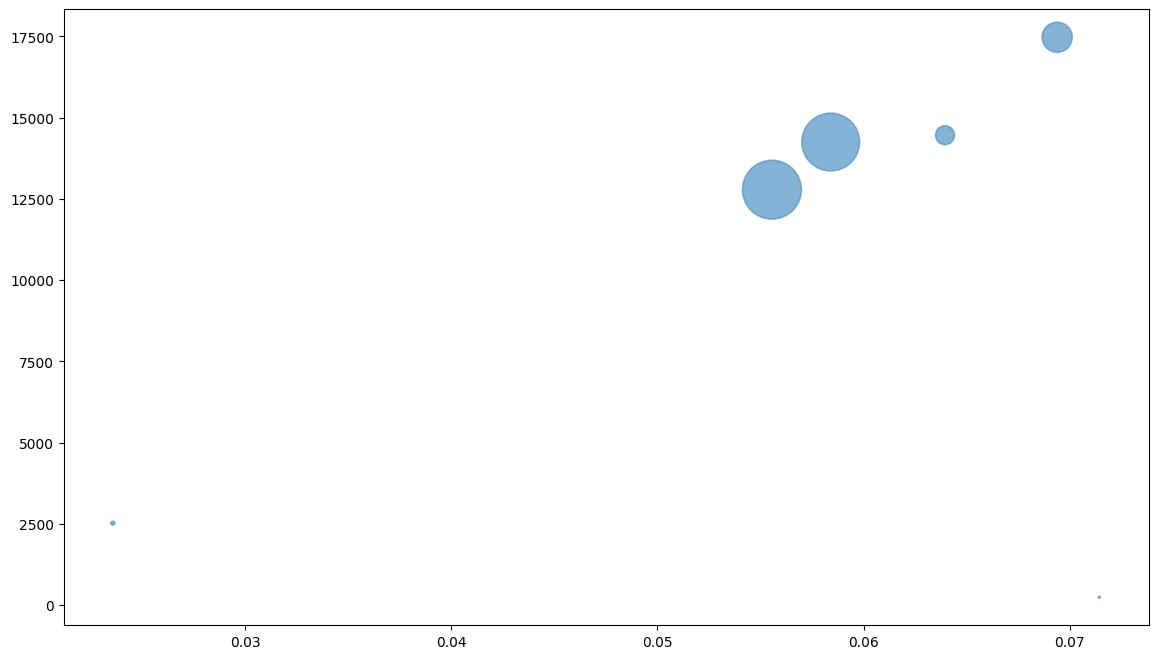

In [24]:
plotar_matriz_retencao_ltv_mes(
    matriz_canais,
    coluna_grupo="canal_aquisicao",
    titulo="Matriz Retenção x LTV por Canal",
    # caminho_saida=OUTPUT_DIR / f"matriz_retencao_ltv_canal_mes_{MES_REFERENCIA}.png"
)

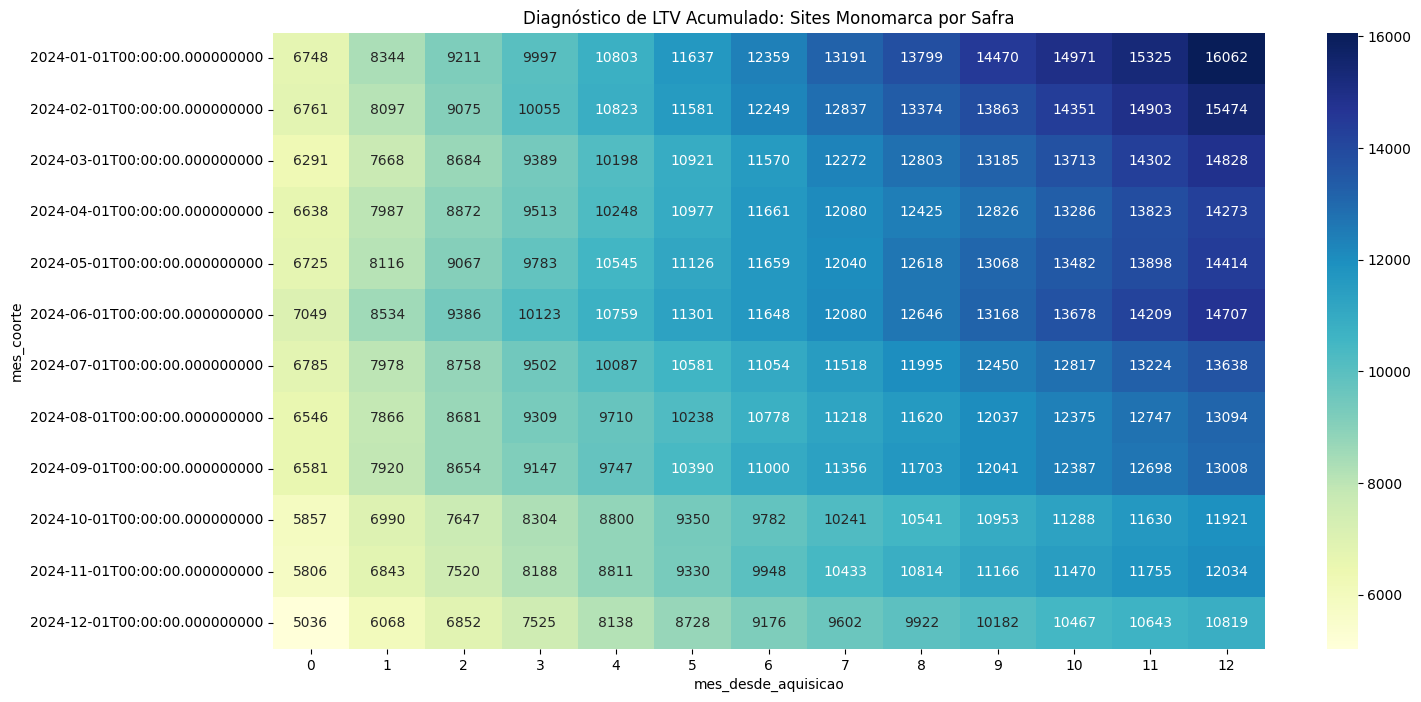

In [ ]:
# 1. Filtrar apenas o subcanal ofensor
df_mono = df[df["subcanal_aquisicao"] == "Sites Monomarca"].copy()


# Garantir que é datetime
df_mono["mes_coorte"] = pd.to_datetime(df_mono["mes_coorte"])

# Filtro
df_mono = (
    df_mono
    .assign(mes_coorte=lambda x: pd.to_datetime(x["mes_coorte"], errors="coerce"))
    .loc[lambda x: x["mes_coorte"].dt.year >= 2024]
)


# 2. Pivotar a base para ver o LTV acumulado de cada Safra (Linha) ao longo dos meses (Colunas)
matriz_diagnostico = df_mono.pivot_table(
    index="mes_coorte",
    columns="mes_desde_aquisicao",
    values="ltv_medio_por_paciente",
    aggfunc="mean"
)

# Exibir as primeiras safras e meses para avaliar as linhas horizontalmente
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 8))
sns.heatmap(matriz_diagnostico.iloc[:12, :13], annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Diagnóstico de LTV Acumulado: Sites Monomarca por Safra")
plt.show()

In [ ]:
# Filtrar o LTV exatamente no Mês 3 de vida do paciente
df_m3 = df_mono[df_mono["mes_desde_aquisicao"] == 3].copy()

# Criar uma coluna com o Ano da Safra
df_m3["ano_coorte"] = df_m3["mes_coorte"].dt.year

# Calcular a média ponderada do LTV no Mês 3 por ano
resumo_anos = df_m3.groupby("ano_coorte").agg(
    pacientes_totais=("tamanho_coorte", "sum"),
    ltv_medio_no_mes_3=("ltv_medio_por_paciente", "mean")
).reset_index()

print("--- Comparativo de Evolução do Canal (LTV no Mês 3) ---")
print(resumo_anos)

--- Comparativo de Evolução do Canal (LTV no Mês 3) ---
   ano_coorte  pacientes_totais  ltv_medio_no_mes_3
0        2023             26934         6933.537500
1        2024             37903         9236.198333
2        2025             36792         4934.334167
3        2026              2862         2182.090000


In [ ]:
# Agrupar a receita total do primeiro mês (Mês 0) por Grupo de Exames dentro do Monomarca
if "grupo_exames" in df_mono.columns:
    mix_produtos = df_mono[df_mono["mes_desde_aquisicao"] == 0].groupby("grupo_exames").agg(
        volume_pacientes=("tamanho_coorte", "sum"),
        receita_inicial=("receita_mes", "sum")
    ).reset_index()
    
    mix_produtos["share_pacientes_%"] = (mix_produtos["volume_pacientes"] / mix_produtos["volume_pacientes"].sum()) * 100
    print(mix_produtos.sort_values(by="share_pacientes_%", ascending=False))
else:
    print("A coluna 'grupo_exames' não está nesta base. Verifique o notebook LTV_Matriz_Retencao_2.ipynb")

A coluna 'grupo_exames' não está nesta base. Verifique o notebook LTV_Matriz_Retencao_2.ipynb
